# TDA — Amsterdam Centre (canal network) vs Eindhoven North (peri-urban)
Improved visualisations with per-figure interpretation annotations.

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import rasterio
import gudhi

os.makedirs("output", exist_ok=True)

# ── colour palette ────────────────────────────────────────────
AMS_COL   = "#2A7DC9"   # steelblue  (Amsterdam)
EHV_COL   = "#C94F2A"   # burnt orange (Eindhoven)
AMS_LIGHT = "#A8CCE8"
EHV_LIGHT = "#EDBBAA"

CITIES = ["Amsterdam Centre", "Eindhoven North"]
PATHS  = {"Amsterdam Centre": "data/amsterdam_centre_strip.tif",
           "Eindhoven North":  "data/eindhoven_north_strip.tif"}
MAX_SIZE = 700   # cap for critical-point grid (px per side)

### Utilities
Functions for data loading, processing, and TDA computations.

In [9]:
def load_tif(path):
    with rasterio.open(path) as src:
        elev = src.read(1).astype(float)
        nodata = src.nodata
    if nodata is not None:
        elev[elev == nodata] = np.nan
    return elev

def downsample(data, max_size=MAX_SIZE):
    h, w = data.shape
    factor = max(1, max(h, w) // max_size)
    return data[::factor, ::factor], factor

def find_critical_points(elev):
    rows, cols = elev.shape
    is_min = np.zeros((rows, cols), bool)
    is_max = np.zeros((rows, cols), bool)
    is_sad = np.zeros((rows, cols), bool)
    pad = np.pad(elev, 1, mode="constant", constant_values=np.nan)
    for r in range(rows):
        for c in range(cols):
            center = elev[r, c]
            if np.isnan(center):
                continue
            nbrs = pad[r:r+3, c:c+3].flatten()
            nbrs = np.delete(nbrs, 4)
            nbrs = nbrs[~np.isnan(nbrs)]
            if len(nbrs) < 3:
                continue
            if center < np.min(nbrs):
                is_min[r, c] = True
            elif center > np.max(nbrs):
                is_max[r, c] = True
            else:
                diff = nbrs - center
                if np.sum(np.diff(np.sign(diff)) != 0) >= 2:
                    is_sad[r, c] = True
    return is_min, is_max, is_sad

def compute_persistence(elev):
    filled = elev.copy()
    nan_mask = np.isnan(filled)
    if nan_mask.any():
        filled[nan_mask] = np.nanmean(filled)
    cc = gudhi.CubicalComplex(
        dimensions=list(filled.shape),
        top_dimensional_cells=filled.flatten()
    )
    cc.compute_persistence()
    return cc.persistence(), cc

def pairs_0d(pairs):
    return [(b, d) for dim, (b, d) in pairs
            if dim == 0 and not np.isinf(d)]

def annotate_box(ax, text, xy=(0.02, 0.97), fontsize=8.5, color="0.25"):
    ax.annotate(text, xy=xy, xycoords="axes fraction",
                va="top", ha="left", fontsize=fontsize, color=color,
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="0.85", alpha=0.88))

### Data Loading
Ensure the `.tif` files are available in the specified directory.

In [12]:
print("Loading data …")
try:
    data = {c: load_tif(PATHS[c]) for c in CITIES}
    ams, ehv = data["Amsterdam Centre"], data["Eindhoven North"]
    print(f"  Amsterdam  shape={ams.shape}  range=[{np.nanmin(ams):.2f}, {np.nanmax(ams):.2f}] m")
    print(f"  Eindhoven  shape={ehv.shape}  range=[{np.nanmin(ehv):.2f}, {np.nanmax(ehv):.2f}] m")
except Exception as e:
    print(f"Error: {e}. Please ensure data files exist in the /data folder.")

Loading data …
  Amsterdam  shape=(25000, 10000)  range=[-10.02, 16.53] m
  Eindhoven  shape=(12500, 20000)  range=[10.40, 35.04] m


### Step 1 — Raw Elevation Heatmaps

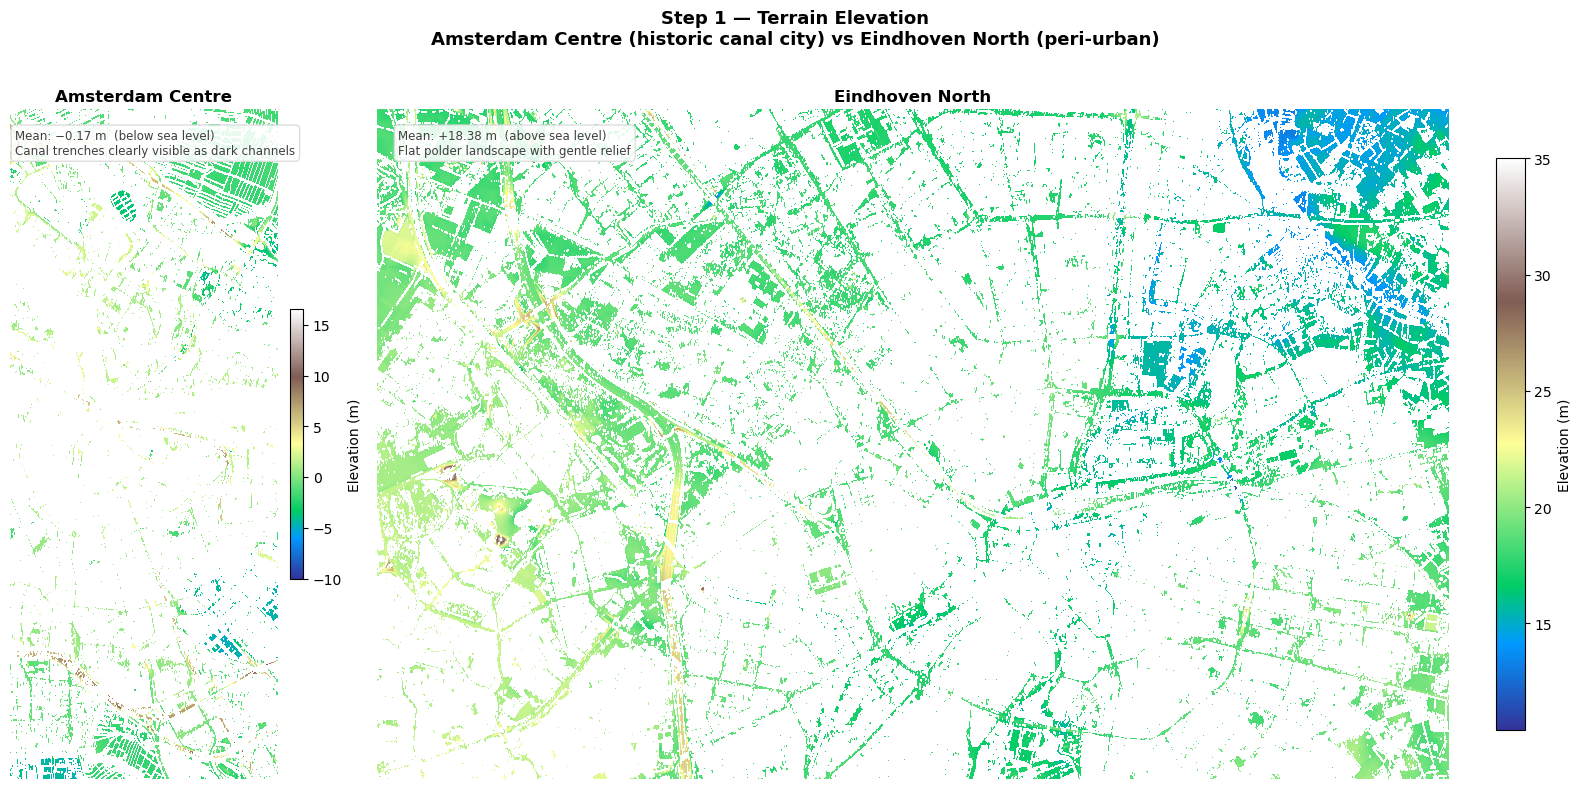

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8),
                         gridspec_kw={"width_ratios":
                                      [ams.shape[1]/ams.shape[0],
                                       ehv.shape[1]/ehv.shape[0]]})
fig.suptitle("Step 1 — Terrain Elevation\n"
             "Amsterdam Centre (historic canal city) vs Eindhoven North (peri-urban)",
             fontsize=13, fontweight="bold", y=1.01)

descs = [
    "Mean: −0.17 m  (below sea level)\nCanal trenches clearly visible as dark channels",
    "Mean: +18.38 m  (above sea level)\nFlat polder landscape with gentle relief"
]
for ax, d, title, desc in zip(axes, [ams, ehv], CITIES, descs):
    im = ax.imshow(d, cmap="terrain", vmin=np.nanmin(d), vmax=np.nanmax(d))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("off")
    plt.colorbar(im, ax=ax, label="Elevation (m)", fraction=0.046, pad=0.04, shrink=0.8)
    annotate_box(ax, desc)

plt.tight_layout()
plt.show()

### Step 2 — Histograms

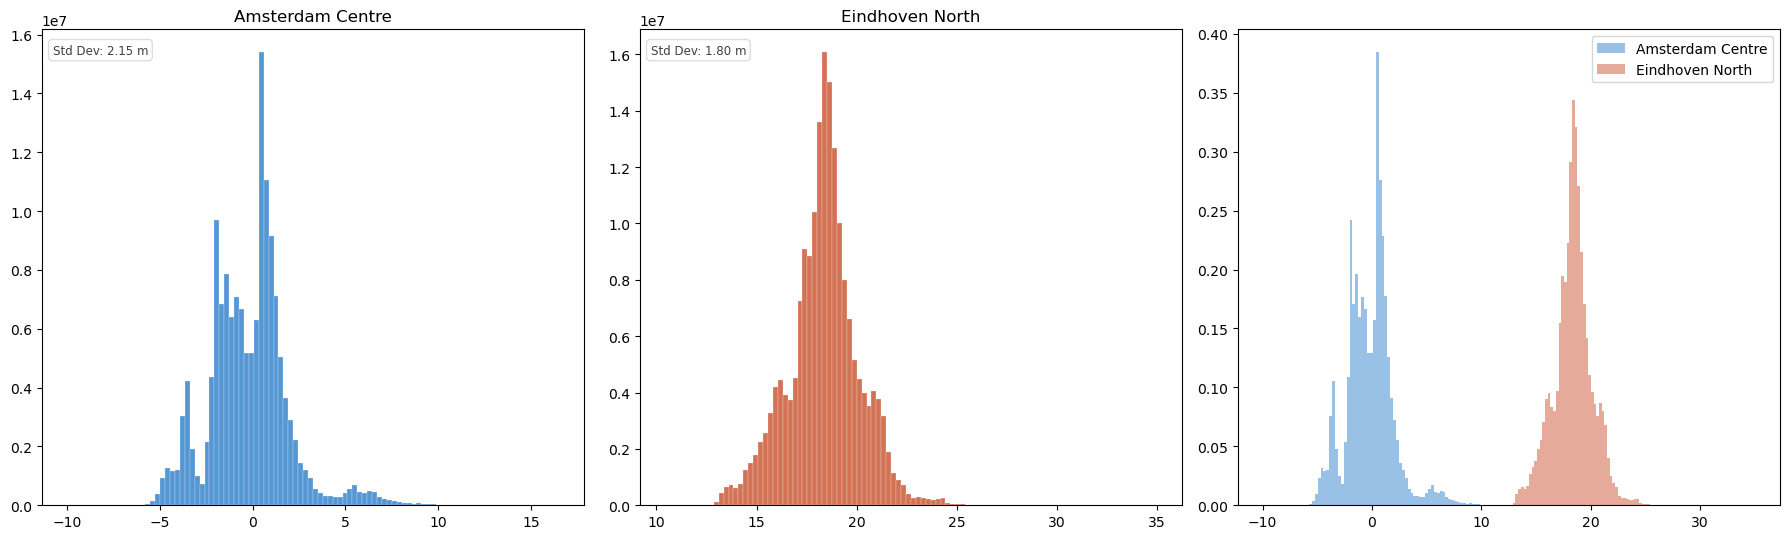

In [15]:
stats = {}
for name, d in data.items():
    v = d[~np.isnan(d)]
    stats[name] = dict(mean=np.mean(v), std=np.std(v), mn=np.min(v), mx=np.max(v))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
for ax, (name, col) in zip(axes[:2], zip(CITIES, [AMS_COL, EHV_COL])):
    v = data[name][~np.isnan(data[name])].flatten()
    ax.hist(v, bins=100, color=col, alpha=0.8, edgecolor="white", linewidth=0.2)
    ax.set_title(name)
    annotate_box(ax, f"Std Dev: {stats[name]['std']:.2f} m")

ax = axes[2]
for name, col in zip(CITIES, [AMS_COL, EHV_COL]):
    v = data[name][~np.isnan(data[name])].flatten()
    ax.hist(v, bins=100, color=col, alpha=0.48, label=name, density=True)
ax.legend()
plt.tight_layout()
plt.show()

### Step 3 — Critical Points

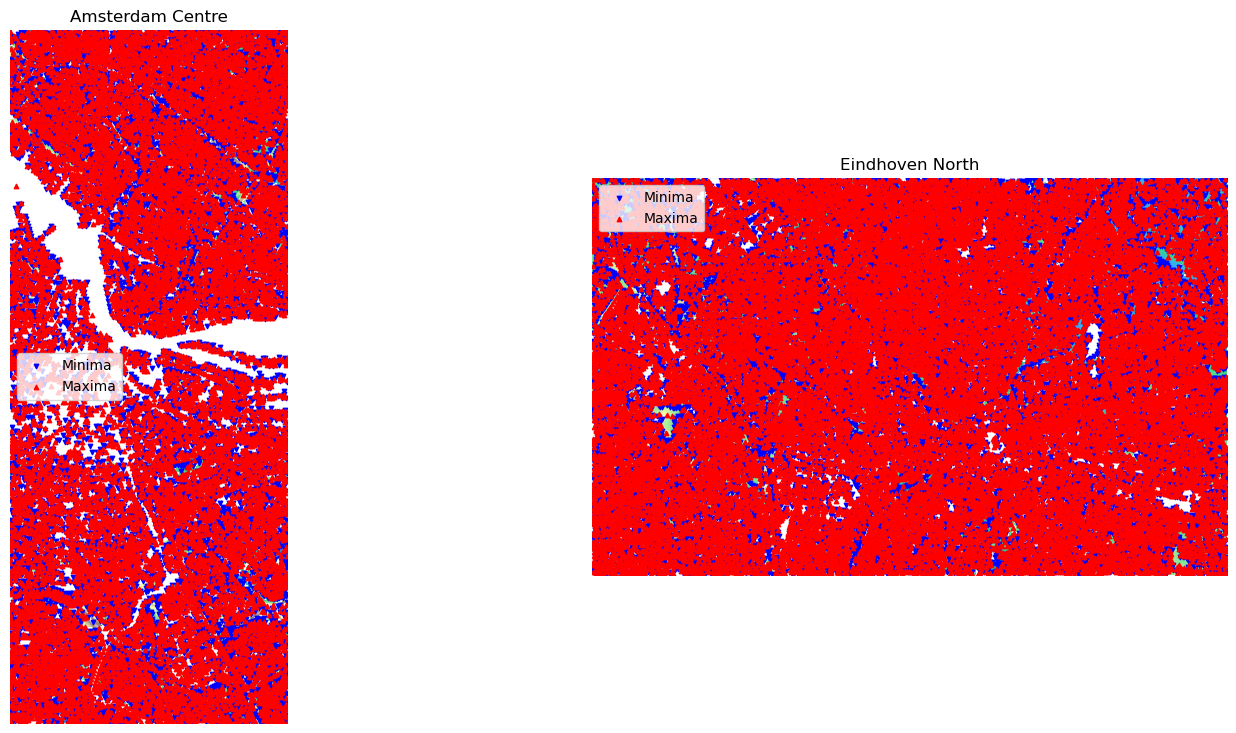

In [16]:
ds = {c: downsample(data[c]) for c in CITIES}
grids = {c: ds[c][0] for c in CITIES}
crit = {c: find_critical_points(grids[c]) for c in CITIES}

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, c in zip(axes, CITIES):
    g, (mn, mx, sd) = grids[c], crit[c]
    ax.imshow(g, cmap="terrain", alpha=0.8)
    ys, xs = np.where(mn); ax.scatter(xs, ys, c="blue", s=10, marker="v", label="Minima")
    ys, xs = np.where(mx); ax.scatter(xs, ys, c="red", s=10, marker="^", label="Maxima")
    ax.set_title(c); ax.legend(); ax.axis("off")
plt.show()

### Step 4 — Persistence Diagrams

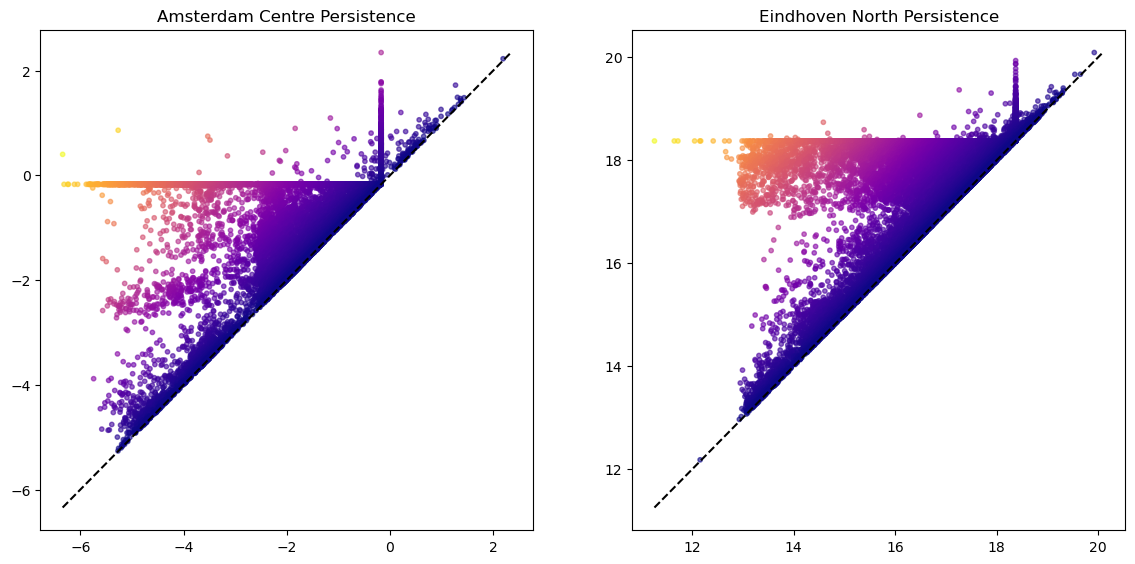

In [17]:
pers = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, c, col in zip(axes, CITIES, [AMS_COL, EHV_COL]):
    pairs, _ = compute_persistence(grids[c])
    p0 = pairs_0d(pairs)
    pers[c] = p0
    births, deaths = np.array([b for b, d in p0]), np.array([d for b, d in p0])
    persist = deaths - births
    sc = ax.scatter(births, deaths, c=persist, cmap="plasma", s=10, alpha=0.6)
    ax.plot([min(births), max(deaths)], [min(births), max(deaths)], "k--")
    ax.set_title(f"{c} Persistence")
plt.show()

### Step 5 — Filtered Minima

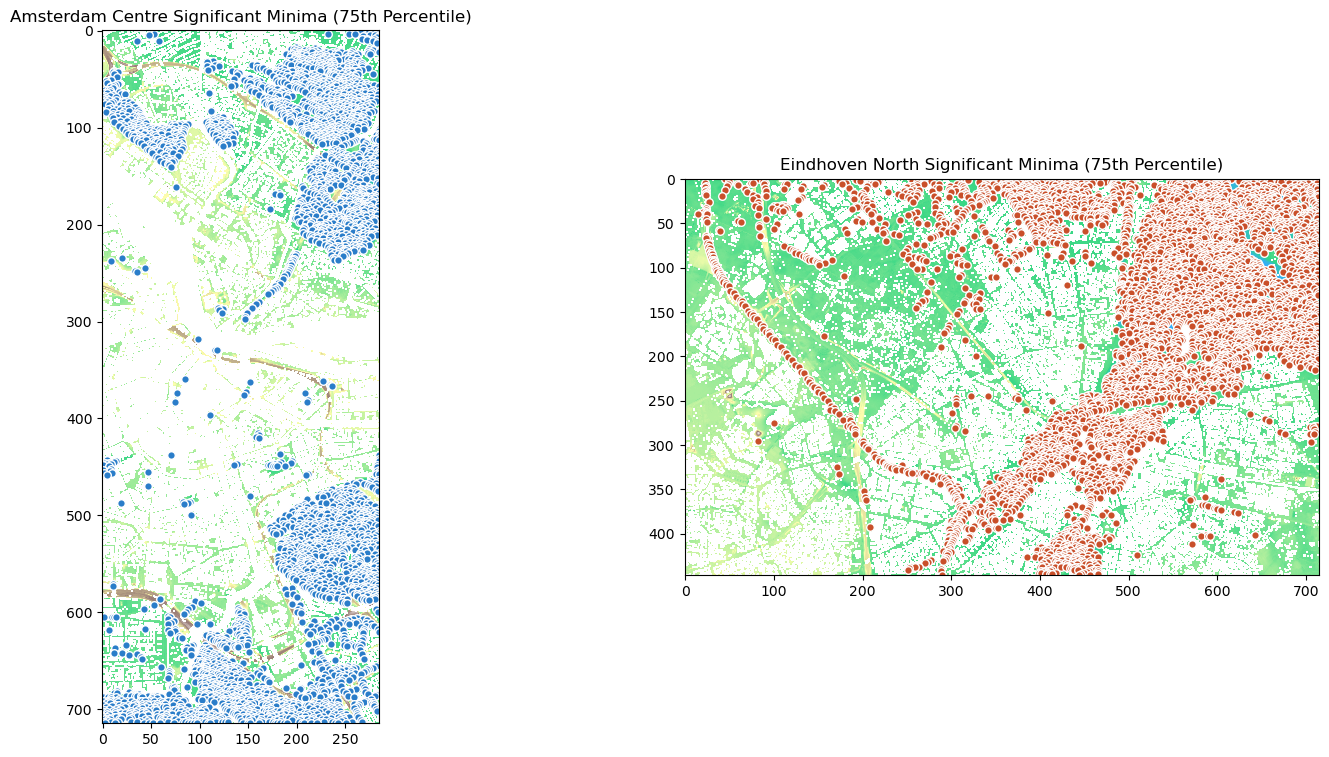

In [18]:
def sig_minima(elev, min_mask, threshold):
    m = np.nanmean(elev)
    sig = np.zeros_like(min_mask)
    ys, xs = np.where(min_mask)
    for y, x in zip(ys, xs):
        if (m - elev[y, x]) >= threshold: sig[y, x] = True
    return sig

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
for ax, c, col in zip(axes, CITIES, [AMS_COL, EHV_COL]):
    g, (mn, _, _) = grids[c], crit[c]
    thresh = np.percentile([d-b for b, d in pers[c]], 75)
    sig = sig_minima(g, mn, thresh)
    ax.imshow(g, cmap="terrain", alpha=0.8)
    ys, xs = np.where(sig); ax.scatter(xs, ys, c=col, s=30, edgecolors="white")
    ax.set_title(f"{c} Significant Minima (75th Percentile)")
plt.show()